# 02 — Preprocessing and ResNet-50 Baseline for CBIS-DDSM Mass Classification

This notebook implements the first publishable baseline for the dissertation: binary malignant-vs-not-malignant classification on the CBIS-DDSM **mass** subset using an ImageNet-pretrained ResNet-50.

The experimental protocol is intentionally conservative:

- only mass cases are used for this baseline;
- the official CBIS-DDSM mass training CSV is used for model development;
- validation is split at **patient level**, not image level;
- the official CBIS-DDSM mass test CSV is kept as a locked final test set;
- all preprocessing, caching, and splitting steps include leakage and alignment checks.

This design is stronger than a random image split because it reduces patient leakage and gives a cleaner estimate of generalisation to unseen patients.



In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Configuration

The paths below match the dissertation project structure in Google Drive. The notebook writes reusable image caches, trained model weights, and result summaries back to Drive so that the experiment can be reproduced after a runtime restart.

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"
DATA_DIR    = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")
JPEG_DIR    = os.path.join(DATA_DIR, "jpeg")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache")
MODEL_DIR   = os.path.join(PROJECT_DIR, "Models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")

for d in [CACHE_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

MODEL_PATH  = os.path.join(MODEL_DIR, "resnet50_mass_baseline_patient_split.pth")
METRICS_PATH = os.path.join(RESULTS_DIR, "resnet50_mass_baseline_metrics.csv")

IMG_SIZE   = 224
BATCH_SIZE = 12
EPOCHS     = 15
LR         = 1e-4
VAL_FRAC   = 0.15
SEED       = 42

## 2. Imports and Reproducibility Controls

The seed settings make the experiment more reproducible across reruns. Exact GPU determinism can still vary slightly across hardware and library versions, so the final dissertation should report the software environment and ideally repeat the final experiment across multiple seeds if time allows.

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "| GPU:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

Device: cuda | GPU: Tesla T4


## 3. Build Image-Level Metadata Tables

CBIS-DDSM can contain more than one abnormality annotation for the same mammogram. For image classification, the data are aggregated to one row per physical mammogram image.

The binary label is defined as:

- `1` = malignant if any abnormality on that image is malignant;
- `0` = not malignant for benign and benign-without-callback cases.

This notebook uses only the **mass** CSV files. Calcification cases are not mixed into this baseline.

In [ ]:
def uid_from(path):
    return str(path).split("/")[-2]


def first_jpeg_from_uid(uid):
    folder = os.path.join(JPEG_DIR, uid)
    if not os.path.isdir(folder):
        return None
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            return os.path.join(folder, fname)
    return None


def build_img_df(case_csv):
    df = pd.read_csv(os.path.join(DATA_DIR, case_csv))
    df["label"] = (df["pathology"].str.upper() == "MALIGNANT").astype(int)
    df["full_jpeg"] = df["image file path"].apply(lambda p: first_jpeg_from_uid(uid_from(p)))

    out = (
        df.dropna(subset=["full_jpeg"])
          .groupby(["patient_id", "left or right breast", "image view"], as_index=False)
          .agg(full_jpeg=("full_jpeg", "first"), label=("label", "max"))
    )
    out["source_csv"] = case_csv
    return out


def load_or_build(case_csv, cache_name):
    cache = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache):
        print("Loading cached metadata:", cache_name)
        return pd.read_csv(cache)
    print("Building metadata:", cache_name)
    out = build_img_df(case_csv)
    out.to_csv(cache, index=False)
    return out


img_df = load_or_build("mass_case_description_train_set.csv", "img_df_mass_train.csv")
img_df_test = load_or_build("mass_case_description_test_set.csv", "img_df_mass_test.csv")

summary = pd.DataFrame({
    "split": ["development", "locked_test"],
    "images": [len(img_df), len(img_df_test)],
    "patients": [img_df["patient_id"].nunique(), img_df_test["patient_id"].nunique()],
    "malignant_rate": [img_df["label"].mean(), img_df_test["label"].mean()],
})
display(summary)

Loading cached metadata: img_df_mass_train.csv
Loading cached metadata: img_df_mass_test.csv


,split,images,patients,malignant_rate
0,development,1231,691,0.489033
1,locked_test,361,201,0.401662


## 4. Preprocess Images and Cache Arrays

Each mammogram is converted to grayscale and resized to `224 × 224` for ResNet-50. The single grayscale channel is later repeated three times to match the ImageNet-pretrained model input.

The cache stores row identifiers as well as labels. This prevents a common notebook failure mode where cached arrays silently become misaligned with the current metadata table.

In [ ]:
def row_keys(df):
    return (
        df["patient_id"].astype(str) + "|" +
        df["left or right breast"].astype(str) + "|" +
        df["image view"].astype(str)
    ).to_numpy()


def preprocess(df, size=IMG_SIZE):
    X = np.zeros((len(df), size, size), dtype=np.uint8)
    y = df["label"].to_numpy(dtype=np.int64)
    for i, path in enumerate(tqdm(df["full_jpeg"].tolist(), desc="preprocessing")):
        X[i] = np.array(
            Image.open(path).convert("L").resize((size, size)),
            dtype=np.uint8,
        )
    return X, y


def cached_arrays(df, name):
    cache = os.path.join(CACHE_DIR, name)
    expected_keys = row_keys(df)
    expected_y = df["label"].to_numpy(dtype=np.int64)

    if os.path.exists(cache):
        d = np.load(cache, allow_pickle=True)
        has_keys = "row_key" in d.files
        keys_match = has_keys and np.array_equal(d["row_key"].astype(str), expected_keys.astype(str))
        labels_match = "y" in d.files and np.array_equal(d["y"], expected_y)
        if keys_match and labels_match:
            print("Loaded validated cache:", name)
            return d["X"], d["y"]
        print("Cache mismatch detected; rebuilding:", name)

    X, y = preprocess(df)
    np.savez_compressed(cache, X=X, y=y, row_key=expected_keys)
    print("Saved validated cache:", name)
    return X, y


X_train_all, y_train_all = cached_arrays(img_df, "mass_train_224.npz")
X_test, y_test = cached_arrays(img_df_test, "mass_test_224.npz")

print("Train array:", X_train_all.shape, "| Test array:", X_test.shape)

Loaded validated cache: mass_train_224.npz
Loaded validated cache: mass_test_224.npz
Train array: (1231, 224, 224) | Test array: (361, 224, 224)


## 5. Visual Sanity Check

Before training, a small sample of preprocessed mammograms is displayed. This is not a performance result; it simply confirms that the cached arrays contain plausible mammogram images after resizing.

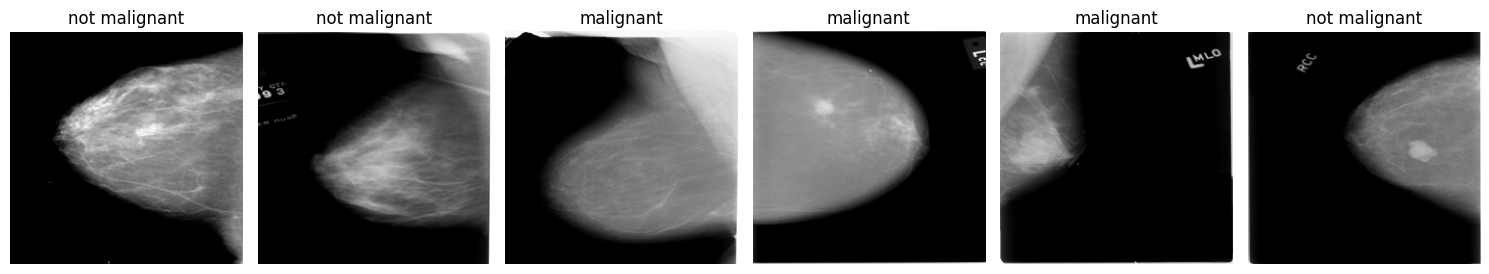

In [ ]:
n_show = min(6, len(X_train_all))
fig, ax = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
if n_show == 1:
    ax = [ax]
for a, i in zip(ax, random.sample(range(len(X_train_all)), n_show)):
    a.imshow(X_train_all[i], cmap="gray")
    a.set_title("malignant" if y_train_all[i] else "not malignant")
    a.axis("off")
plt.tight_layout()
plt.show()

## 6. Patient-Level Train/Validation Split and DataLoaders

The validation set is carved only from the official mass training set. Splitting is performed by `patient_id`, so mammograms from the same patient cannot appear in both training and validation.

The official mass test set is not used for model selection. It remains locked until the final evaluation section.

In [ ]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class ArrayDS(Dataset):
    def __init__(self, X, y, train=False):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        t = torch.from_numpy(np.stack([self.X[i]] * 3, axis=0)).float() / 255.0
        if self.train and random.random() < 0.5:
            t = torch.flip(t, dims=[2])
        return (t - MEAN) / STD, int(self.y[i])


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)

train_groups = img_df["patient_id"].to_numpy()
test_groups = img_df_test["patient_id"].to_numpy()

assert len(train_groups) == len(X_train_all) == len(y_train_all), "Development metadata and arrays are misaligned"
assert len(test_groups) == len(X_test) == len(y_test), "Test metadata and arrays are misaligned"
assert np.array_equal(img_df["label"].to_numpy(dtype=np.int64), y_train_all), "Development labels do not match cached arrays"
assert np.array_equal(img_df_test["label"].to_numpy(dtype=np.int64), y_test), "Test labels do not match cached arrays"
assert set(train_groups).isdisjoint(set(test_groups)), "Patient leakage between development and locked test sets"

gss = GroupShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
tr_idx, val_idx = next(gss.split(X_train_all, y_train_all, groups=train_groups))

assert set(train_groups[tr_idx]).isdisjoint(set(train_groups[val_idx])), "Patient leakage between train and validation sets"

train_loader = DataLoader(
    ArrayDS(X_train_all[tr_idx], y_train_all[tr_idx], train=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=generator,
)
val_loader = DataLoader(
    ArrayDS(X_train_all[val_idx], y_train_all[val_idx], train=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=generator,
)
test_loader = DataLoader(
    ArrayDS(X_test, y_test, train=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=generator,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "locked_test"],
    "images": [len(tr_idx), len(val_idx), len(y_test)],
    "patients": [len(set(train_groups[tr_idx])), len(set(train_groups[val_idx])), len(set(test_groups))],
    "malignant_rate": [y_train_all[tr_idx].mean(), y_train_all[val_idx].mean(), y_test.mean()],
})
display(split_summary)

,split,images,patients,malignant_rate
0,train,1048,587,0.480916
1,validation,183,104,0.535519
2,locked_test,361,201,0.401662


## 7. ResNet-50 Baseline Model

ResNet-50 is used as a strong, standard ImageNet-pretrained convolutional baseline. The final classification layer is replaced with a two-class head for malignant-vs-not-malignant prediction.

This baseline is intentionally simple: it provides a transparent reference point before moving to DINOv2 and multimodal experiments.

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


## 8. Training and Model Selection

The model is selected using validation AUC only. The locked test set is not inspected during training or model selection.

In [ ]:
@torch.no_grad()
def eval_probs(loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        p = torch.softmax(model(x.to(device)), dim=1)[:, 1].cpu().numpy()
        ps.extend(p.tolist())
        ys.extend(y.tolist())
    return np.array(ys), np.array(ps)


history = []
best_auc = -np.inf

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for x, y in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)

    train_loss = running / len(tr_idx)
    yv, pv = eval_probs(val_loader)
    val_auc = roc_auc_score(yv, pv)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_auc": val_auc})

    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} | val AUC {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({k: v.cpu() for k, v in model.state_dict().items()}, MODEL_PATH)

history_df = pd.DataFrame(history)
display(history_df)
print(f"Best validation AUC: {best_auc:.4f}")
print("Saved best model to:", MODEL_PATH)

epoch 1:   0%|          | 0/88 [00:00<?, ?it/s]

epoch 01 | train loss 0.6599 | val AUC 0.6445


epoch 2:   0%|          | 0/88 [00:00<?, ?it/s]

epoch 02 | train loss 0.5593 | val AUC 0.6894


epoch 3:   0%|          | 0/88 [00:00<?, ?it/s]

...

epoch 14 | train loss 0.0630 | val AUC 0.7983


epoch 15:   0%|          | 0/88 [00:00<?, ?it/s]

epoch 15 | train loss 0.0545 | val AUC 0.8285


,epoch,train_loss,val_auc
0,1,0.659881,0.644538
1,2,0.559322,0.689436
2,3,0.472075,0.746218
3,4,0.390438,0.778872
4,5,0.307425,0.823049
5,6,0.215693,0.817407
6,7,0.156090,0.823289
7,8,0.115488,0.797959
8,9,0.175921,0.793998
9,10,0.129977,0.849340


Best validation AUC: 0.8493
Saved best model to: /content/drive/MyDrive/BreastCancer_dissertation/Models/resnet50_mass_baseline_patient_split.pth


## 9. Locked Test-Set Evaluation

This section evaluates the selected model once on the official CBIS-DDSM mass test set. These metrics are the main baseline results to report, alongside a clear note that CBIS-DDSM is enriched and does not reflect real screening prevalence.

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

yt, pt = eval_probs(test_loader)
pred = (pt >= 0.5).astype(int)

metrics = {
    "auc": roc_auc_score(yt, pt),
    "accuracy": accuracy_score(yt, pred),
    "balanced_accuracy": balanced_accuracy_score(yt, pred),
    "f1": f1_score(yt, pred),
    "precision": precision_score(yt, pred),
    "recall_sensitivity": recall_score(yt, pred),
}

cm = confusion_matrix(yt, pred)
tn, fp, fn, tp = cm.ravel()
metrics["specificity"] = tn / (tn + fp) if (tn + fp) else np.nan

metrics_df = pd.DataFrame([metrics])
display(metrics_df.round(4))
metrics_df.to_csv(METRICS_PATH, index=False)

print("Classification report")
print(classification_report(yt, pred, target_names=["not malignant", "malignant"]))
print("Saved metrics to:", METRICS_PATH)

,auc,accuracy,balanced_accuracy,f1,precision,recall_sensitivity,specificity
0,0.7965,0.7091,0.7173,0.6769,0.6111,0.7586,0.6759


Classification report
               precision    recall  f1-score   support

not malignant       0.81      0.68      0.74       216
    malignant       0.61      0.76      0.68       145

     accuracy                           0.71       361
    macro avg       0.71      0.72      0.71       361
 weighted avg       0.73      0.71      0.71       361

Saved metrics to: /content/drive/MyDrive/BreastCancer_dissertation/Results/resnet50_mass_baseline_metrics.csv


## 10. ROC Curve and Confusion Matrix

The ROC curve summarises threshold-independent discrimination. The confusion matrix uses a fixed decision threshold of `0.5`, so threshold-dependent metrics should be interpreted with the class balance of CBIS-DDSM in mind.

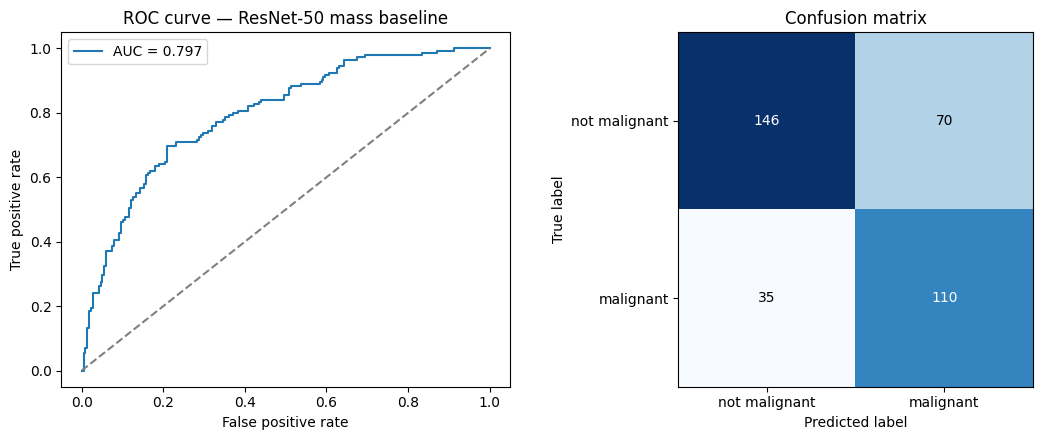

In [ ]:
fpr, tpr, _ = roc_curve(yt, pt)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(fpr, tpr, label=f"AUC = {metrics['auc']:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set_xlabel("False positive rate")
ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve — ResNet-50 mass baseline")
ax[0].legend()

ax[1].imshow(cm, cmap="Blues")
ax[1].set_title("Confusion matrix")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["not malignant", "malignant"])
ax[1].set_yticks([0, 1])
ax[1].set_yticklabels(["not malignant", "malignant"])
ax[1].set_xlabel("Predicted label")
ax[1].set_ylabel("True label")
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 11. Baseline Summary for Dissertation/Paper

This notebook establishes a ResNet-50 baseline for CBIS-DDSM mass classification under a leakage-controlled protocol.

**Protocol summary**

- Task: binary mass classification, malignant vs not malignant.
- Development data: official CBIS-DDSM mass training set.
- Validation: patient-level split from the development set.
- Final evaluation: official CBIS-DDSM mass test set, locked during training.
- Leakage controls: patient-disjoint train/validation split and patient-disjoint development/test check.
- Preprocessing: grayscale mammograms resized to `224 × 224`, then repeated to three channels for ImageNet-pretrained ResNet-50.
- Augmentation: horizontal flipping during training only.
- Model selection: best validation AUC.

**Interpretation notes**

CBIS-DDSM is an enriched diagnostic dataset and is approximately balanced compared with real screening populations. Therefore, AUC, sensitivity, specificity, and balanced accuracy are more informative than accuracy alone. The final dissertation should clearly state that these results estimate performance on CBIS-DDSM-style curated cases, not real-world screening prevalence.

**Next steps**

The trained ResNet-50 model can now be used as the baseline for Grad-CAM analysis, comparison with DINOv2, and later multimodal experiments using clinical metadata.